In [1]:
# !pip install --upgrade pip --quiet
# !pip install transformers==4.30.2 --quiet
# !pip install timm==0.4.12 --quiet
# !pip install ftfy==6.1.1 --quiet
# !pip install spacy==3.4.1 --quiet
# !pip install fairscale==0.4.4 --quiet
# !pip install apache_beam[gcp]>=2.48.0

# # To use the newly installed versions, restart the runtime.
# exit()

In [1]:
import requests
import os
import urllib
import json
import io
from io import BytesIO
from typing import Sequence
from typing import Iterator
from typing import Iterable
from typing import Tuple
from typing import Optional
from typing import Dict
from typing import List
from typing import Any

import apache_beam as beam
from apache_beam.ml.inference.base import PredictionResult
from apache_beam.options.pipeline_options import PipelineOptions
from apache_beam.options.pipeline_options import SetupOptions
from apache_beam.ml.inference.base import KeyedModelHandler
from apache_beam.ml.inference.base import PredictionResult
from apache_beam.ml.inference.base import RunInference
from apache_beam.ml.inference.pytorch_inference import PytorchModelHandlerTensor
from apache_beam.ml.inference.pytorch_inference import PytorchModelHandlerKeyedTensor
from transformers import CLIPProcessor
from transformers import CLIPTokenizer
from transformers import CLIPModel
from transformers import CLIPConfig
from transformers import CLIPFeatureExtractor
import torch
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import logging

/home/divya/miniconda3/envs/divya/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-04-30 14:38:54.542694: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-30 14:38:55.279090: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# !git lfs install
# !git clone https://huggingface.co/openai/clip-vit-base-patch32

In [3]:
# CLIP model and component configs paths
clip_feature_extractor_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/preprocessor_config.json'
clip_tokenizer_vocab_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/vocab.json'
clip_merges_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/merges.txt'
clip_model_config_path = '//home/divya/Early_blip/clip-vit-base-patch32/config.json'
clip_state_dict_path = '/home/divya/Early_blip/clip-vit-base-patch32/pytorch_model.bin'


In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
# !git clone https://github.com/salesforce/BLIP
%cd /home/divya/Early_blip/BLIP

/home/divya/Early_blip/BLIP


In [6]:
from BLIP.models.blip import blip_decoder

# !gdown 'https://storage.googleapis.com/sfr-vision-language-research/BLIP/models/model*_base_caption.pth'
# # The blip model is saved as a checkpoint, load it and save it as a state dict since RunInference required
# # a state dict for model instantiation
blip_state_dict_path = '/home/divya/Early_blip/BLIP/model*_base_caption.pth'
# torch.save(torch.load('/home/divya/Early_blip/BLIP/model*_base_caption.pth')['model'], blip_state_dict_path)

In [7]:
class ReadImagesFromUrl(beam.DoFn):
    def process(self, element):
        if element.startswith('http://') or element.startswith('https://'):
            # Read image from URL
            try:
                image_bytes = urllib.request.urlopen(element).read()
                image = Image.open(io.BytesIO(image_bytes))
                yield element, image
            except Exception as e:
                logging.error(f"Error reading image from URL {element}: {e}")
        else:
            # Assume element is a file path
            try:
                image = Image.open(element)
                yield element, image
            except Exception as e:
                logging.error(f"Error reading image from file path {element}: {e}")



class FormatCaptions(beam.DoFn):
    """
    Save the image names and their most relevant captions after CLIP ranking to a JSON file.
    """
    def __init__(self, output_file: str, number_of_top_captions: int):
        self._output_file = output_file
        self._number_of_top_captions = number_of_top_captions
        self._output_data = []

    def process(self, element: Tuple[str, List[str]]):
        image_url, caption_list = element
        caption_list = caption_list[:self._number_of_top_captions]
        img_name = os.path.basename(image_url).rsplit('.')[0]

        # Collect captions for JSON serialization
        captions = [{'caption': caption_prob_pair[0], 'probability': float(caption_prob_pair[1])} 
            for caption_rank, caption_prob_pair in enumerate(caption_list)]
        
        # Append to the output data
        self._output_data.append({'image_name': img_name, 'captions': captions})

    def finish_bundle(self):
        # Save the output data to a JSON file
        with open(self._output_file, 'w') as f:
            json.dump(self._output_data, f)

In [8]:
class PreprocessBLIPInput(beam.DoFn):

  """
  Process the raw image input to a format suitable for BLIP inference. The processed
  images are duplicated to the number of desired captions per image.

  Preprocessing transformation taken from:
  https://github.com/salesforce/BLIP/blob/d10be550b2974e17ea72e74edc7948c9e5eab884/predict.py
  """

  def __init__(self, captions_per_image: int):
    self._captions_per_image = captions_per_image

  def setup(self):

    # Initialize the image transformer.
    self._transform = transforms.Compose([
      transforms.Resize((384, 384),interpolation=InterpolationMode.BICUBIC),
      transforms.ToTensor(),
      transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
    ])

  def process(self, element):
    image_url, image = element
    # The following lines provide a workaround to turn off BatchElements.
    preprocessed_img = self._transform(image).unsqueeze(0)
    preprocessed_img = preprocessed_img.repeat(self._captions_per_image, 1, 1, 1)
    # preprocessed_img = preprocessed_img.to(device)
    # Parse the processed input to a dictionary to a format suitable for RunInference.
    preprocessed_dict = {'inputs': preprocessed_img}

    return [(image_url, preprocessed_dict)]

class PostprocessBLIPOutput(beam.DoFn):
  """
  Process the PredictionResult to get the generated image captions
  """
  def process(self, element : Tuple[str, Iterable[PredictionResult]]):
    image_url, prediction = element

    return [(image_url, prediction.inference)]

In [9]:
class PreprocessCLIPInput(beam.DoFn):

  """
  Process the image-caption pair to a format suitable for CLIP inference.

  After grouping the raw images with the generated captions, we need to
  preprocess them before passing them to the ranking stage (CLIP model).
  """

  def __init__(self,
               feature_extractor_config_path: str,
               tokenizer_vocab_config_path: str,
               merges_file_config_path: str):

    self._feature_extractor_config_path = feature_extractor_config_path
    self._tokenizer_vocab_config_path = tokenizer_vocab_config_path
    self._merges_file_config_path = merges_file_config_path


  def setup(self):

    # Initialize the CLIP feature extractor.
    feature_extractor_config = CLIPConfig.from_pretrained(self._feature_extractor_config_path)
    feature_extractor = CLIPFeatureExtractor(feature_extractor_config)

    # Initialize the CLIP tokenizer.
    tokenizer = CLIPTokenizer(self._tokenizer_vocab_config_path,
                              self._merges_file_config_path)

    # Initialize the CLIP processor used to process the image-caption pair.
    self._processor = CLIPProcessor(feature_extractor=feature_extractor,
                                    tokenizer=tokenizer)

  def process(self, element: Tuple[str, Dict[str, List[Any]]]):

    image_url, image_captions_pair = element
    # Unpack the image and captions after grouping them with 'CoGroupByKey()'.
    image = image_captions_pair['image'][0]
    captions = image_captions_pair['captions'][0]
    preprocessed_clip_input = self._processor(images = image,
                                              text = captions,
                                              return_tensors="pt",
                                              padding=True)

    image_url_caption_pair = (image_url, captions)
    return [(image_url_caption_pair, preprocessed_clip_input)]


class RankCLIPOutput(beam.DoFn):
  """
  Process the output of CLIP to get the captions sorted by ranking order.

  The logits are the output of the CLIP model. Here, we apply a softmax activation
  function to the logits to get the probabilistic distribution of the relevance
  of each caption to the target image. After that, we sort the captions in descending
  order with respect to the probabilities as a caption-probability pair.
  """

  def process(self, element : Tuple[Tuple[str, List[str]], Iterable[PredictionResult]]):
    (image_url, captions), prediction = element
    prediction_results = prediction.inference
    prediction_probs = prediction_results.softmax(dim=-1).cpu().detach().numpy()
    ranking = np.argsort(-prediction_probs)
    sorted_caption_prob_pair = [(captions[idx], prediction_probs[idx]) for idx in ranking]

    return [(image_url, sorted_caption_prob_pair)]

In [10]:
MAX_CAPTION_LENGTH = 80
MIN_CAPTION_LENGTH = 10
# Increasing Beam search might improve the quality of the captions,
# but also results in more compute time
NUM_BEAMS = 1


In [11]:
def blip_keyed_tensor_inference_fn(
    batch: Sequence[Dict[str, torch.Tensor]],
    model: torch.nn.Module,
    device: str,
    inference_args: Optional[Dict[str, Any]] = None,
    model_id: Optional[str] = None,
) -> Iterable[PredictionResult]:
  # By default, Beam batches inputs for bulk inference and calls model(batch)
  # Since we want to call model.generate on a single unbatched input (BLIP/CLIP
  # don't handle batched inputs), we define a custom inference function.
  captions = model.generate(batch[0]['inputs'],
                            sample=True,
                            num_beams=NUM_BEAMS,
                            max_length=MAX_CAPTION_LENGTH,
                            min_length=MIN_CAPTION_LENGTH)
  return [PredictionResult(batch[0], captions, model_id)]


BLIP_model_handler = PytorchModelHandlerKeyedTensor(
    state_dict_path=blip_state_dict_path,
    model_class=blip_decoder,
    inference_fn=blip_keyed_tensor_inference_fn,
    max_batch_size=1)

BLIP_keyed_model_handler = KeyedModelHandler(BLIP_model_handler)

In [12]:
def clip_keyed_tensor_inference_fn(
    batch: Sequence[Dict[str, torch.Tensor]],
    model: torch.nn.Module,
    device: str,
    inference_args: Optional[Dict[str, Any]] = None,
    model_id: Optional[str] = None,
) -> Iterable[PredictionResult]:
  # By default, Beam batches inputs for bulk inference and calls model(batch)
  # Since we want to call model on a single unbatched input (BLIP/CLIP don't
  # handle batched inputs), we define a custom inference function.
  output = model(**batch[0], **inference_args)
  return [PredictionResult(batch[0], output.logits_per_image[0], model_id)]


CLIP_model_handler = PytorchModelHandlerKeyedTensor(
    state_dict_path=clip_state_dict_path,
    model_class=CLIPModel,
    model_params={'config': CLIPConfig.from_pretrained(clip_model_config_path)},
    inference_fn=clip_keyed_tensor_inference_fn,
    max_batch_size=1)

CLIP_keyed_model_handler = KeyedModelHandler(CLIP_model_handler)


In [13]:
import os
import random

# Path to the folder containing images
folder_path = '/home/divya/Image_captioning/TF_image_caption/images/val2014'

# List all files in the folder
image_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(len(image_files))

# Specify the fraction of images to sample
fraction_to_sample = 0.0001  # Change this to the desired fraction

# Calculate the number of images to sample
num_images_to_sample = int(len(image_files) * fraction_to_sample)

# Randomly select a subset of images
# selected_image_files = random.sample(image_files, num_images_to_sample)
selected_image_files = random.sample(image_files, num_images_to_sample)


# Now you have a list of selected image files that you can use as input
print(len(selected_image_files))


40504
4


In [14]:
# from datasets import load_dataset
# # Load the Flickr30k dataset
# dataset = load_dataset("HuggingFaceM4/flickr30k", download_mode = "/home/divya/Early_blip")

# # Print information about the dataset
# print(dataset)



In [15]:
# a function to determine whether a string is a URL or not
def is_url(string):
    try:
        result = parse.urlparse(string)
        return all([result.scheme, result.netloc, result.path])
    except:
        return False
    
# a function to load an image
def load_image(image_path):
    if is_url(image_path):
        return Image.open(requests.get(image_path, stream=True).raw)
    elif os.path.exists(image_path):
        return Image.open(image_path)

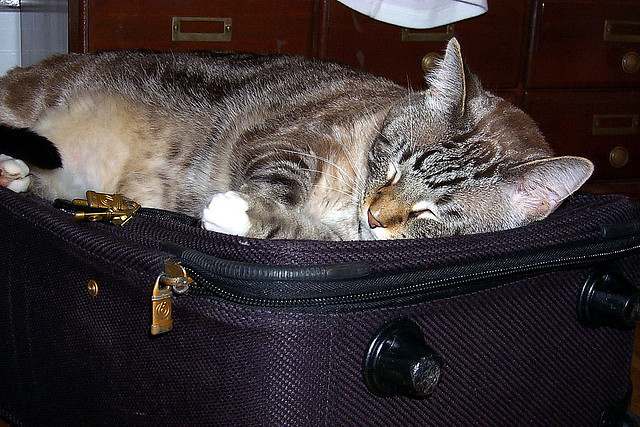

In [16]:
load_image(selected_image_files[1])
# load_image(images_url[1])
# load_image(images_url[2])

In [17]:
# Number of captions generated per image.
NUM_CAPTIONS_PER_IMAGE = 5

# Number of top captions to display.
NUM_TOP_CAPTIONS_TO_DISPLAY = 1

PATH_TO_SAVE = "/home/divya/Early_blip/coco_synthetic/captions_and_image.json"


In [18]:
print(PATH_TO_SAVE[1])

h


In [19]:
class SaveImagesWithCaptions(beam.DoFn):
    def __init__(self, save_paths):
        self.save_paths = save_paths
        self.image_captions = {}  # Dictionary to store image captions

    def process(self, element):
        image_id = element[0]
        captions = element[1]
        image_name = self.save_paths[image_id].split('/')[-1]  # Extract image name from the path
        self.image_captions[image_name] = captions  # Store captions in the dictionary

        yield None  # Yielding None as there's no output required for the pipeline

    def finish_bundle(self):
        # Save the image captions dictionary to a JSON file
        with open('image_captions.json', 'w') as f:
            json.dump(self.image_captions, f)

In [20]:
# selected_image_files = [dataset[0]["image"], dataset[1]["image"]]

In [21]:
import time
import apache_beam as beam
# Define a custom DoFn to count elements
# Define a custom DoFn to count elements
class CountElements(beam.DoFn):
    def process(self, element):
        yield len(element)
        # Log the number of samples processed after each sample
        print("Samples processed: {}".format(self.sample_count))
        self.sample_count += 1

    def start_bundle(self):
        self.sample_count = 0

# Initialize variables for time and sample count
start_time = time.time()
sample_count = 0

with beam.Pipeline() as pipeline:
    read_images = (
        pipeline
        | "ReadUrl" >> beam.Create(selected_image_files)
        | "ReadImages" >> beam.ParDo(ReadImagesFromUrl()))

    blip_caption_generation = (
        read_images
        | "PreprocessBlipInput" >> beam.ParDo(PreprocessBLIPInput(NUM_CAPTIONS_PER_IMAGE))
        | "GenerateCaptions" >> RunInference(BLIP_keyed_model_handler)
        | "PostprocessCaptions" >> beam.ParDo(PostprocessBLIPOutput()))

    clip_captions_ranking = (
        {'image': read_images, 'captions': blip_caption_generation}
        | "CreateImageCaptionPair" >> beam.CoGroupByKey()
        | "PreprocessClipInput" >> beam.ParDo(
            PreprocessCLIPInput(
                clip_feature_extractor_config_path,
                clip_tokenizer_vocab_config_path,
                clip_merges_config_path))
        | "GetRankingLogits" >> RunInference(CLIP_keyed_model_handler)
        | "RankClipOutput" >> beam.ParDo(RankCLIPOutput())
    )

    clip_captions_ranking | "FormatCaptions" >> beam.ParDo(FormatCaptions(PATH_TO_SAVE, NUM_TOP_CAPTIONS_TO_DISPLAY))

    # Apply a ParDo to count the number of samples
    count_samples = (
        read_images
        | "Count Samples" >> beam.ParDo(CountElements())
        | "Sum Samples" >> beam.CombineGlobally(sum))

    # Collect the total number of samples processed
    sample_count = pipeline.run().get(count_samples)

# Calculate the time taken
end_time = time.time()
time_taken = end_time - start_time

# Print the time taken and the total number of samples processed
print("Time taken: {:.2f} seconds".format(time_taken))
print("Total number of samples processed:", sample_count)


Samples processed: 0
Samples processed: 1
Samples processed: 2
Samples processed: 3


ERROR:apache_beam.runners.common:Error(s) in loading state_dict for CLIPModel:
	Unexpected key(s) in state_dict: "text_model.embeddings.position_ids", "vision_model.embeddings.position_ids".  [while running '[21]: GetRankingLogits/BeamML_RunInference']
Traceback (most recent call last):
  File "apache_beam/runners/common.py", line 1500, in apache_beam.runners.common.DoFnRunner._invoke_lifecycle_method
  File "apache_beam/runners/common.py", line 564, in apache_beam.runners.common.DoFnInvoker.invoke_setup
  File "/home/divya/miniconda3/envs/divya/lib/python3.11/site-packages/apache_beam/ml/inference/base.py", line 1380, in setup
    self._model = self._load_model()
                  ^^^^^^^^^^^^^^^^^^
  File "/home/divya/miniconda3/envs/divya/lib/python3.11/site-packages/apache_beam/ml/inference/base.py", line 1352, in _load_model
    model = self._shared_model_handle.acquire(load, tag=model_tag)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/divya/mini

RuntimeError: Error(s) in loading state_dict for CLIPModel:
	Unexpected key(s) in state_dict: "text_model.embeddings.position_ids", "vision_model.embeddings.position_ids".  [while running '[21]: GetRankingLogits/BeamML_RunInference']

In [1]:
import json

# Define the path to the JSON file
json_file_path = '/home/divya/Early_blip/captions_and_image/captions_and_image.json'

# Load the JSON file
with open(json_file_path, 'r') as f:
    data = json.load(f)

# Process the loaded data
for item in data:
    image_name = item['image_name']
    captions = item['captions']
    
    # Process each caption for the image
    for caption in captions:
        caption_text = caption['caption']
        caption_probability = caption['probability']
        
        # Do something with the image name, caption text, and probability
        print(f"Image: {image_name}, Caption: {caption_text}, Probability: {caption_probability}")

Image: 5073552229, Caption: two young children working in an art room, Probability: 0.36964547634124756
Image: 5073552229, Caption: children are working on construction paper in the classroom, Probability: 0.28591787815093994
Image: 5073552229, Caption: two children are drawing in their classroom, Probability: 0.19619931280612946
Image: 7643799764, Caption: there are two people that are shooting on the fence, Probability: 0.8375031352043152
Image: 7643799764, Caption: two people standing behind a glass looking into a bathroom, Probability: 0.13900572061538696
Image: 7643799764, Caption: a man and woman playing on the nintendo wii, Probability: 0.013029413297772408
Image: 947664583, Caption: the child has on a swim suit, diving in a pool, Probability: 0.5949075222015381
Image: 947664583, Caption: a little girl in the pool jumping into the water, Probability: 0.15105558931827545
Image: 947664583, Caption: a young child in a swimming pool on an air boat, Probability: 0.1462119221687317
Im

In [1]:
load_image(selected_image_files[-2])

NameError: name 'load_image' is not defined

In [3]:
import requests
import os
import urllib
import json
import io
from io import BytesIO
from typing import Sequence, Iterator, Iterable, Tuple, Optional, Dict, List, Any
from transformers import CLIPProcessor, CLIPTokenizer, CLIPModel, CLIPConfig, CLIPFeatureExtractor
import torch
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
import numpy as np
from PIL import Image
import logging
import tqdm

# CLIP model and component configs paths
clip_feature_extractor_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/preprocessor_config.json'
clip_tokenizer_vocab_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/vocab.json'
clip_merges_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/merges.txt'
clip_model_config_path = '/home/divya/Early_blip/clip-vit-base-patch32/config.json'
clip_state_dict_path = '/home/divya/Early_blip/clip-vit-base-patch32/pytorch_model.bin'

from BLIP.models.blip import blip_decoder

blip_state_dict_path = '/home/divya/Early_blip/BLIP/model*_base_caption.pth'

class ReadImagesFromUrl:
    def __call__(self, element):
        if element.startswith('http://') or element.startswith('https://'):
            # Read image from URL
            try:
                image_bytes = urllib.request.urlopen(element).read()
                image = Image.open(io.BytesIO(image_bytes))
                return element, image
            except Exception as e:
                logging.error(f"Error reading image from URL {element}: {e}")
                return None, None
        else:
            # Assume element is a file path
            try:
                image = Image.open(element)
                return element, image
            except Exception as e:
                logging.error(f"Error reading image from file path {element}: {e}")
                return None, None

class FormatCaptions:
    def __init__(self, output_file: str, number_of_top_captions: int):
        self._output_file = output_file
        self._number_of_top_captions = number_of_top_captions
        self._output_data = []

    def __call__(self, element: Tuple[str, List[str]]):
        image_url, caption_list = element
        caption_list = caption_list[:self._number_of_top_captions]
        img_name = os.path.basename(image_url).rsplit('.')[0]

        captions = [{'caption': caption_prob_pair[0], 'probability': float(caption_prob_pair[1])} 
            for caption_rank, caption_prob_pair in enumerate(caption_list)]
        
        self._output_data.append({'image_name': img_name, 'captions': captions})

    def finish(self):
        with open(self._output_file, 'w') as f:
            json.dump(self._output_data, f)

class PreprocessBLIPInput:
    def __init__(self, captions_per_image: int):
        self._captions_per_image = captions_per_image
        self._transform = transforms.Compose([
            transforms.Resize((384, 384),interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
        ])

    def __call__(self, element):
        image_url, image = element
        preprocessed_img = self._transform(image).unsqueeze(0).repeat(self._captions_per_image, 1, 1, 1)
        preprocessed_dict = {'inputs': preprocessed_img}
        return image_url, preprocessed_dict

class PostprocessBLIPOutput:
    def __call__(self, element : Tuple[str, Iterable[PredictionResult]]):
        image_url, prediction = element
        return image_url, prediction.inference

class PreprocessCLIPInput:
    def __init__(self,
               feature_extractor_config_path: str,
               tokenizer_vocab_config_path: str,
               merges_file_config_path: str):
        self._feature_extractor_config_path = feature_extractor_config_path
        self._tokenizer_vocab_config_path = tokenizer_vocab_config_path
        self._merges_file_config_path = merges_file_config_path

    def __call__(self, element: Tuple[str, Dict[str, List[Any]]]):
        image_url, image_captions_pair = element
        image = image_captions_pair['image'][0]
        captions = image_captions_pair['captions'][0]
        processor = CLIPProcessor(
            feature_extractor=CLIPFeatureExtractor(CLIPConfig.from_pretrained(self._feature_extractor_config_path)),
            tokenizer=CLIPTokenizer(self._tokenizer_vocab_config_path, self._merges_file_config_path)
        )
        preprocessed_clip_input = processor(images=image, text=captions, return_tensors="pt", padding=True)
        image_url_caption_pair = (image_url, captions)
        return image_url_caption_pair, preprocessed_clip_input

class RankCLIPOutput:
    def __call__(self, element : Tuple[Tuple[str, List[str]], Iterable[PredictionResult]]):
        (image_url, captions), prediction = element
        prediction_results = prediction.inference
        prediction_probs = prediction_results.softmax(dim=-1).cpu().detach().numpy()
        ranking = np.argsort(-prediction_probs)
        sorted_caption_prob_pair = [(captions[idx], prediction_probs[idx]) for idx in ranking]
        return image_url, sorted_caption_prob_pair

MAX_CAPTION_LENGTH = 80
MIN_CAPTION_LENGTH = 10
NUM_BEAMS = 1

def blip_keyed_tensor_inference_fn(
    batch: Sequence[Dict[str, torch.Tensor]],
    model: torch.nn.Module,
    device: str,
    inference_args: Optional[Dict[str, Any]] = None,
    model_id: Optional[str] = None,
) -> Iterable[PredictionResult]:
    captions = model.generate(batch[0]['inputs'],
                            sample=True,
                            num_beams=NUM_BEAMS,
                            max_length=MAX_CAPTION_LENGTH,
                            min_length=MIN_CAPTION_LENGTH)
    return [PredictionResult(batch[0], captions, model_id)]

def clip_keyed_tensor_inference_fn(
    batch: Sequence[Dict[str, torch.Tensor]],
    model: torch.nn.Module,
    device: str,
    inference_args: Optional[Dict[str, Any]] = None,
    model_id: Optional[str] = None,
) -> Iterable[PredictionResult]:
    output = model(**batch[0], **inference_args)
    return [PredictionResult(batch[0], output.logits_per_image[0], model_id)]

class BLIPModelHandler:
    def __init__(self, state_dict_path: str):
        self.state_dict_path = state_dict_path
        self.model = torch.load(self.state_dict_path)

    def infer(self, batch):
        return blip_keyed_tensor_inference_fn(batch, self.model, "cpu")

class CLIPModelHandler:
    def __init__(self, state_dict_path: str, config_path: str):
        self.state_dict_path = state_dict_path
        self.config_path = config_path
        self.model = CLIPModel.from_pretrained(self.state_dict_path, config=self.config_path)

    def infer(self, batch):
        return clip_keyed_tensor_inference_fn(batch, self.model, "cpu")

# Create instances of model handlers
blip_model_handler = BLIPModelHandler(blip_state_dict_path)
clip_model_handler = CLIPModelHandler(clip_state_dict_path, clip_model_config_path)

# Define functions to read images from URLs
def read_images_from_url(image_urls):
    images = []
    for url in image_urls:
        if url.startswith('http://') or url.startswith('https://'):
            try:
                image_bytes = requests.get(url).content
                image = Image.open(BytesIO(image_bytes))
                images.append((url, image))
            except Exception as e:
                logging.error(f"Error reading image from URL {url}: {e}")
        else:
            logging.error(f"Invalid URL format: {url}")
    return images

# Define functions to read images from local file paths
def read_images_from_file(file_paths):
    images = []
    for path in file_paths:
        if os.path.exists(path):
            try:
                image = Image.open(path)
                images.append((path, image))
            except Exception as e:
                logging.error(f"Error reading image from file path {path}: {e}")
        else:
            logging.error(f"File not found: {path}")
    return images

# Specify the paths to image files or URLs
image_files_or_urls = [
    '/path/to/image1.jpg',
    '/path/to/image2.jpg',
    'https://example.com/image3.jpg'
]

# Read images
images = read_images_from_url(image_files_or_urls)

# Preprocess images for BLIP
preprocessed_images = [PreprocessBLIPInput(NUM_CAPTIONS_PER_IMAGE)(image) for image in images]

# Generate captions using BLIP
blip_captions = [blip_model_handler.infer([preprocessed_image]) for preprocessed_image in preprocessed_images]

# Rank captions using CLIP
clipped_captions = [(images[i][0], blip_captions[i]) for i in range(len(images))]
clipped_captions = [PreprocessCLIPInput(
    clip_feature_extractor_config_path,
    clip_tokenizer_vocab_config_path,
    clip_merges_config_path)(clipped_caption) for clipped_caption in clipped_captions]
clipped_captions = [clip_model_handler.infer([clipped_caption]) for clipped_caption in clipped_captions]

# Format and save captions
formatted_captions = [FormatCaptions(PATH_TO_SAVE, NUM_TOP_CAPTIONS_TO_DISPLAY)(clipped_caption) for clipped_caption in clipped_captions]

# Call the finish method of FormatCaptions to save the JSON file
formatted_captions.finish()

/home/divya/miniconda3/envs/divya/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-03-21 13:19:18.100144: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-21 13:19:19.155439: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


ModuleNotFoundError: No module named 'models'